# Labwork 3: COVID-QU Dataset Analysis

This notebook analyzes the COVID-QU dataset for medical diagnosis tasks.

**Dataset**: [COVID-QU Dataset](https://www.kaggle.com/datasets/anasmohammedtahir/covidqu)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print("Libraries imported successfully!")


2026-02-04 15:56:45.435007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770220605.616781      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770220605.671184      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770220606.104615      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770220606.104675      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770220606.104677      55 computation_placer.cc:177] computation placer alr

Libraries imported successfully!


## 1. Dataset Loading

Using kagglehub to download the COVID-QU dataset.


In [2]:
# Check if running on Kaggle or locally
if os.path.exists('/kaggle/working'):
    # Running on Kaggle - use kagglehub
    import kagglehub
    
    # Download latest version
    path = kagglehub.dataset_download("anasmohammedtahir/covidqu")
    print("Path to dataset files:", path)
    DATA_PATH = path
    OUTPUT_PATH = '/kaggle/working'
else:
    # Running locally - use practical 3 directory
    DATA_PATH = 'practical 3'
    OUTPUT_PATH = '.'
    print(f"Running locally - using data from: {DATA_PATH}")

print(f"\nData path: {DATA_PATH}")
print(f"Output path: {OUTPUT_PATH}")


Path to dataset files: /kaggle/input/covidqu

Data path: /kaggle/input/covidqu
Output path: /kaggle/working


## 2. Dataset Exploration

Exploring the structure and contents of the dataset.


In [3]:
print(f"Contents of {DATA_PATH}:")
if os.path.exists(DATA_PATH):
    all_items = os.listdir(DATA_PATH)
    for item in sorted(all_items):
        item_path = os.path.join(DATA_PATH, item)
        if os.path.isfile(item_path):
            size = os.path.getsize(item_path)
            size_mb = size / (1024 * 1024)
            print(f"  FILE: {item} ({size_mb:.2f} MB)")
        elif os.path.isdir(item_path):
            # Count files in directory
            file_count = len([f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f))])
            print(f"  DIR:  {item}/ ({file_count} files)")
else:
    print(f"Path {DATA_PATH} does not exist!")

# Check for zip files that might need extraction
if os.path.exists(DATA_PATH):
    zip_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.zip')]
    if zip_files:
        print(f"\nFound {len(zip_files)} zip file(s). Checking if extraction is needed...")
        for zip_file in zip_files:
            zip_path = os.path.join(DATA_PATH, zip_file)
            extract_dir = os.path.join(DATA_PATH, zip_file.replace('.zip', ''))
            if not os.path.exists(extract_dir):
                print(f"  {zip_file} may need to be extracted to {extract_dir}")


Contents of /kaggle/input/covidqu:
  FILE: COVID-QU-Ex dataset.txt (0.00 MB)
  DIR:  Infection Segmentation Data/ (0 files)
  DIR:  Lung Segmentation Data/ (0 files)


In [4]:
# Detailed directory structure exploration
print("Exploring directory structure in detail...\n")

def print_directory_structure(root_path, max_depth=3, current_depth=0, max_items=20):
    """Print directory structure to understand dataset organization"""
    if current_depth >= max_depth:
        return
    
    try:
        items = sorted(os.listdir(root_path))[:max_items]
        for item in items:
            item_path = os.path.join(root_path, item)
            indent = "  " * current_depth
            
            if os.path.isdir(item_path):
                # Count files in directory
                try:
                    subitems = os.listdir(item_path)
                    file_count = sum(1 for f in subitems if os.path.isfile(os.path.join(item_path, f)))
                    dir_count = sum(1 for d in subitems if os.path.isdir(os.path.join(item_path, d)))
                    print(f"{indent}📁 {item}/ ({file_count} files, {dir_count} dirs)")
                    
                    # Recursively explore if not too deep
                    if current_depth < max_depth - 1:
                        print_directory_structure(item_path, max_depth, current_depth + 1, max_items=10)
                except PermissionError:
                    print(f"{indent}📁 {item}/ (permission denied)")
            else:
                size = os.path.getsize(item_path) / 1024  # KB
                print(f"{indent}📄 {item} ({size:.2f} KB)")
    except PermissionError:
        print(f"{'  ' * current_depth}Permission denied: {root_path}")

print_directory_structure(DATA_PATH, max_depth=4)


Exploring directory structure in detail...

📄 COVID-QU-Ex dataset.txt (2.91 KB)
📁 Infection Segmentation Data/ (0 files, 1 dirs)
  📁 Infection Segmentation Data/ (0 files, 3 dirs)
    📁 Test/ (0 files, 3 dirs)
      📁 COVID-19/ (0 files, 3 dirs)
      📁 Non-COVID/ (0 files, 3 dirs)
      📁 Normal/ (0 files, 3 dirs)
    📁 Train/ (0 files, 3 dirs)
      📁 COVID-19/ (0 files, 3 dirs)
      📁 Non-COVID/ (0 files, 3 dirs)
      📁 Normal/ (0 files, 3 dirs)
    📁 Val/ (0 files, 3 dirs)
      📁 COVID-19/ (0 files, 3 dirs)
      📁 Non-COVID/ (0 files, 3 dirs)
      📁 Normal/ (0 files, 3 dirs)
📁 Lung Segmentation Data/ (0 files, 1 dirs)
  📁 Lung Segmentation Data/ (0 files, 3 dirs)
    📁 Test/ (0 files, 3 dirs)
      📁 COVID-19/ (0 files, 2 dirs)
      📁 Non-COVID/ (0 files, 2 dirs)
      📁 Normal/ (0 files, 2 dirs)
    📁 Train/ (0 files, 3 dirs)
      📁 COVID-19/ (0 files, 2 dirs)
      📁 Non-COVID/ (0 files, 2 dirs)
      📁 Normal/ (0 files, 2 dirs)
    📁 Val/ (0 files, 3 dirs)
      📁 COVID-1

In [5]:
# Explore the dataset structure - look for image directories
# COVID-QU dataset typically has classes: COVID-19, Non-COVID infections, Normal
# Also has segmentation masks

print("Exploring dataset structure for images...\n")

# Find all image files
image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']
image_files = []
mask_files = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        file_lower = file.lower()
        if any(file_lower.endswith(ext) for ext in image_extensions):
            file_path = os.path.join(root, file)
            if 'mask' in file_lower or 'segmentation' in file_lower or 'annotation' in file_lower:
                mask_files.append(file_path)
            else:
                image_files.append(file_path)

print(f"Found {len(image_files)} image files")
print(f"Found {len(mask_files)} mask/segmentation files")

# Try to identify class directories
class_dirs = {}
possible_class_names = ['covid', 'normal', 'non-covid', 'pneumonia', 'viral', 'bacterial', 'infection']

for root, dirs, files in os.walk(DATA_PATH):
    for dir_name in dirs:
        dir_lower = dir_name.lower()
        for class_name in possible_class_names:
            if class_name in dir_lower:
                dir_path = os.path.join(root, dir_name)
                # Count images in this directory
                img_count = len([f for f in os.listdir(dir_path) 
                               if any(f.lower().endswith(ext) for ext in image_extensions)
                               and 'mask' not in f.lower() and 'segmentation' not in f.lower()])
                if img_count > 0:
                    if class_name not in class_dirs or img_count > class_dirs[class_name][1]:
                        class_dirs[class_name] = (dir_path, img_count)

if class_dirs:
    print(f"\nFound {len(class_dirs)} class directories:")
    for class_name, (dir_path, count) in class_dirs.items():
        print(f"  {class_name}: {dir_path} ({count} images)")
else:
    print("\nNo clear class directories found. Images may be in a flat structure.")
    # Check if images are organized by subdirectories
    subdirs = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
    print(f"\nFound {len(subdirs)} subdirectories. Checking structure...")
    for subdir in subdirs[:10]:  # Check first 10
        subdir_path = os.path.join(DATA_PATH, subdir)
        img_count = len([f for f in os.listdir(subdir_path) 
                        if any(f.lower().endswith(ext) for ext in image_extensions)
                        and 'mask' not in f.lower()])
        if img_count > 0:
            print(f"  {subdir}: {img_count} images")


Exploring dataset structure for images...

Found 85318 image files
Found 0 mask/segmentation files

Found 1 class directories:
  infection: /kaggle/input/covidqu/Infection Segmentation Data/Infection Segmentation Data/Train/COVID-19/infection masks (1864 images)


## 3. Load and Organize Images

Loading images from the dataset and organizing them by class.


In [6]:
# Function to load and preprocess images
def load_and_preprocess_image(image_path, target_size=(224, 224), grayscale=False):
    """Load and preprocess an image for model input"""
    try:
        if grayscale:
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        else:
            img = cv2.imread(image_path, cv2.IMREAD_COLOR)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if img is None:
            # Try with PIL as fallback
            img = np.array(Image.open(image_path))
            if len(img.shape) == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) if not grayscale else img
            elif len(img.shape) == 3 and img.shape[2] == 4:
                img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB) if not grayscale else cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
        
        if img is None:
            # Create a black image if loading fails
            if grayscale:
                img = np.zeros(target_size, dtype=np.uint8)
            else:
                img = np.zeros((*target_size, 3), dtype=np.uint8)
        else:
            img = cv2.resize(img, target_size)
        
        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0
        
        # Add channel dimension if grayscale
        if grayscale and len(img.shape) == 2:
            img = np.expand_dims(img, axis=-1)
        
        return img
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        if grayscale:
            return np.zeros((*target_size, 1), dtype=np.float32)
        else:
            return np.zeros((*target_size, 3), dtype=np.float32)

# Organize images by class - specifically for COVID-QU dataset structure
def organize_images_by_class(data_path, use_infection_data=True):
    """
    Organize images into class-based structure for COVID-QU dataset.
    
    Dataset structure:
    - Infection Segmentation Data/Infection Segmentation Data/Train|Val|Test/COVID-19|Non-COVID|Normal/images/
    - Lung Segmentation Data/Lung Segmentation Data/Train|Val|Test/COVID-19|Non-COVID|Normal/images/
    """
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']
    
    # Class mapping for COVID-QU dataset
    class_mapping = {
        'covid-19': 0,
        'covid': 0,
        'non-covid': 1,
        'noncovid': 1,
        'normal': 2
    }
    
    images = []
    labels = []
    image_paths = []
    
    print("Searching for images in COVID-QU dataset structure...")
    
    # Determine which dataset to use
    if use_infection_data:
        dataset_name = "Infection Segmentation Data"
    else:
        dataset_name = "Lung Segmentation Data"
    
    # Look for the dataset directory
    dataset_path = None
    for root, dirs, files in os.walk(data_path):
        if dataset_name in root:
            # Check if this is the right level (should have Train/Val/Test subdirs)
            if any(d in dirs for d in ['Train', 'Val', 'Test', 'train', 'val', 'test']):
                dataset_path = root
                break
    
    if dataset_path is None:
        # Try alternative: look for nested structure
        for root, dirs, files in os.walk(data_path):
            if dataset_name in os.path.basename(root):
                # Check parent or child for Train/Val/Test
                if os.path.exists(root):
                    for item in os.listdir(root):
                        item_path = os.path.join(root, item)
                        if os.path.isdir(item_path):
                            try:
                                subdirs = os.listdir(item_path)
                                if any(d in subdirs for d in ['Train', 'Val', 'Test', 'train', 'val', 'test']):
                                    dataset_path = item_path
                                    break
                            except:
                                pass
                if dataset_path:
                    break
    
    if dataset_path is None:
        print(f"Warning: Could not find {dataset_name} directory structure")
        print("Trying to find any Train/Val/Test directories...")
        # Fallback: search for any Train/Val/Test directories
        for root, dirs, files in os.walk(data_path):
            root_lower = root.lower()
            if any(skip in root_lower for skip in ['mask', 'segmentation', 'annotation']):
                continue
            if any(d in dirs for d in ['Train', 'Val', 'Test', 'train', 'val', 'test']):
                dataset_path = root
                break
    
    if dataset_path:
        print(f"Found dataset at: {dataset_path}")
        
        # Look for Train, Val, Test directories
        splits = ['Train', 'Val', 'Test', 'train', 'val', 'test']
        for split_name in splits:
            split_path = os.path.join(dataset_path, split_name)
            if not os.path.exists(split_path):
                # Try nested structure
                for root, dirs, files in os.walk(dataset_path):
                    if split_name in dirs:
                        split_path = os.path.join(root, split_name)
                        break
            
            if os.path.exists(split_path):
                print(f"  Processing {split_name} split...")
                
                # Look for class directories (COVID-19, Non-COVID, Normal)
                try:
                    for class_dir in os.listdir(split_path):
                        class_path = os.path.join(split_path, class_dir)
                        if not os.path.isdir(class_path):
                            continue
                        
                        # Determine class label
                        class_label = None
                        class_dir_lower = class_dir.lower()
                        for class_key, label in class_mapping.items():
                            if class_key in class_dir_lower:
                                class_label = label
                                break
                        
                        if class_label is None:
                            continue
                        
                        # Look for images subdirectory
                        images_dir = os.path.join(class_path, 'images')
                        if os.path.exists(images_dir):
                            # Load images from images subdirectory
                            for file in os.listdir(images_dir):
                                if any(file.lower().endswith(ext) for ext in image_extensions):
                                    # Skip mask files
                                    if any(skip in file.lower() for skip in ['mask', 'segmentation', 'annotation']):
                                        continue
                                    
                                    file_path = os.path.join(images_dir, file)
                                    if os.path.isfile(file_path):
                                        images.append(file_path)
                                        labels.append(class_label)
                                        image_paths.append(file_path)
                        else:
                            # Images might be directly in class directory
                            for file in os.listdir(class_path):
                                if any(file.lower().endswith(ext) for ext in image_extensions):
                                    # Skip mask files and mask directories
                                    if any(skip in file.lower() for skip in ['mask', 'segmentation', 'annotation']):
                                        continue
                                    
                                    file_path = os.path.join(class_path, file)
                                    if os.path.isfile(file_path):
                                        images.append(file_path)
                                        labels.append(class_label)
                                        image_paths.append(file_path)
                except Exception as e:
                    print(f"    Error processing {split_path}: {e}")
    
    print(f"Organized {len(images)} images with labels")
    return images, labels, image_paths

# Load and organize images
print("Loading and organizing images...")
print("Using Infection Segmentation Data (set use_infection_data=False to use Lung Segmentation Data)")

# Try Infection Segmentation Data first
image_paths, labels, _ = organize_images_by_class(DATA_PATH, use_infection_data=True)

# If no images found, try Lung Segmentation Data
if len(image_paths) == 0:
    print("\nNo images found in Infection Segmentation Data, trying Lung Segmentation Data...")
    image_paths, labels, _ = organize_images_by_class(DATA_PATH, use_infection_data=False)

print(f"\nTotal labeled images: {len(image_paths)}")
if len(image_paths) > 0:
    print(f"Class distribution:")
    unique_labels, counts = np.unique(labels, return_counts=True)
    class_names = {0: 'COVID-19', 1: 'Non-COVID', 2: 'Normal'}
    for label, count in zip(unique_labels, counts):
        class_name = class_names.get(label, f'Class {label}')
        print(f"  {class_name}: {count} images ({count/len(labels)*100:.2f}%)")
else:
    print("WARNING: No images found! Please check the dataset structure.")


Loading and organizing images...
Using Infection Segmentation Data (set use_infection_data=False to use Lung Segmentation Data)
Searching for images in COVID-QU dataset structure...
Found dataset at: /kaggle/input/covidqu/Infection Segmentation Data/Infection Segmentation Data
  Processing Train split...
  Processing Val split...
  Processing Test split...
Organized 5826 images with labels

Total labeled images: 5826
Class distribution:
  COVID-19: 4370 images (75.01%)
  Normal: 1456 images (24.99%)


In [7]:
# Load actual image data
if len(image_paths) == 0:
    print("\nWARNING: No labeled images found!")
    print("Trying alternative approach - loading all images and inferring classes from directory structure...")
    
    # Alternative: load all images and try to infer classes more aggressively
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']
    all_image_paths = []
    
    for root, dirs, files in os.walk(DATA_PATH):
        root_lower = root.lower()
        # Skip mask/segmentation directories
        if any(skip in root_lower for skip in ['mask', 'segmentation', 'annotation']):
            continue
        
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                # Skip mask files
                if any(skip in file.lower() for skip in ['mask', 'segmentation', 'annotation']):
                    continue
                
                file_path = os.path.join(root, file)
                all_image_paths.append(file_path)
    
    print(f"Found {len(all_image_paths)} total images (excluding masks)")
    
    # Try to infer classes from path
    class_mapping = {
        'covid': 0, 'covid-19': 0,
        'normal': 2,
        'non-covid': 1, 'noncovid': 1, 'non_covid': 1,
        'pneumonia': 1, 'viral': 1, 'bacterial': 1, 'infection': 1
    }
    
    image_paths = []
    labels = []
    
    for img_path in all_image_paths:
        path_lower = img_path.lower()
        class_label = None
        
        # Check path for class indicators
        for class_key, label in class_mapping.items():
            if class_key in path_lower:
                class_label = label
                break
        
        if class_label is not None:
            image_paths.append(img_path)
            labels.append(class_label)
    
    print(f"After class inference: {len(image_paths)} labeled images")

if len(image_paths) > 0:
    print("\nLoading image data (this may take a while)...")
    
    # Use a subset for faster processing during development, or load all
    # Set max_images to None to load all images
    max_images = None  # Change to a number like 5000 for faster testing
    
    if max_images and len(image_paths) > max_images:
        print(f"Loading {max_images} random images for faster processing...")
        indices = np.random.choice(len(image_paths), max_images, replace=False)
        image_paths = [image_paths[i] for i in indices]
        labels = [labels[i] for i in indices]
    
    X = []
    y = []
    
    for i, (img_path, label) in enumerate(zip(image_paths, labels)):
        if (i + 1) % 1000 == 0:
            print(f"  Loaded {i + 1}/{len(image_paths)} images...")
        
        img = load_and_preprocess_image(img_path, target_size=(224, 224), grayscale=False)
        X.append(img)
        y.append(label)
    
    X = np.array(X)
    y = np.array(y)
    
    print(f"\nLoaded {len(X)} images")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    if len(X) > 0:
        print(f"Image dtype: {X.dtype}")
        print(f"Image value range: [{X.min():.3f}, {X.max():.3f}]")
    else:
        print("ERROR: No images were loaded. Please check the dataset structure.")
else:
    print("\nERROR: Could not find any images with class labels.")
    print("Please verify the dataset structure and class directory names.")
    X = np.array([])
    y = np.array([])



Loading image data (this may take a while)...
  Loaded 1000/5826 images...
  Loaded 2000/5826 images...
  Loaded 3000/5826 images...
  Loaded 4000/5826 images...
  Loaded 5000/5826 images...

Loaded 5826 images
X shape: (5826, 224, 224, 3)
y shape: (5826,)
Image dtype: float32
Image value range: [0.000, 1.000]


## 4. Data Visualization

Exploring the data distribution and relationships.


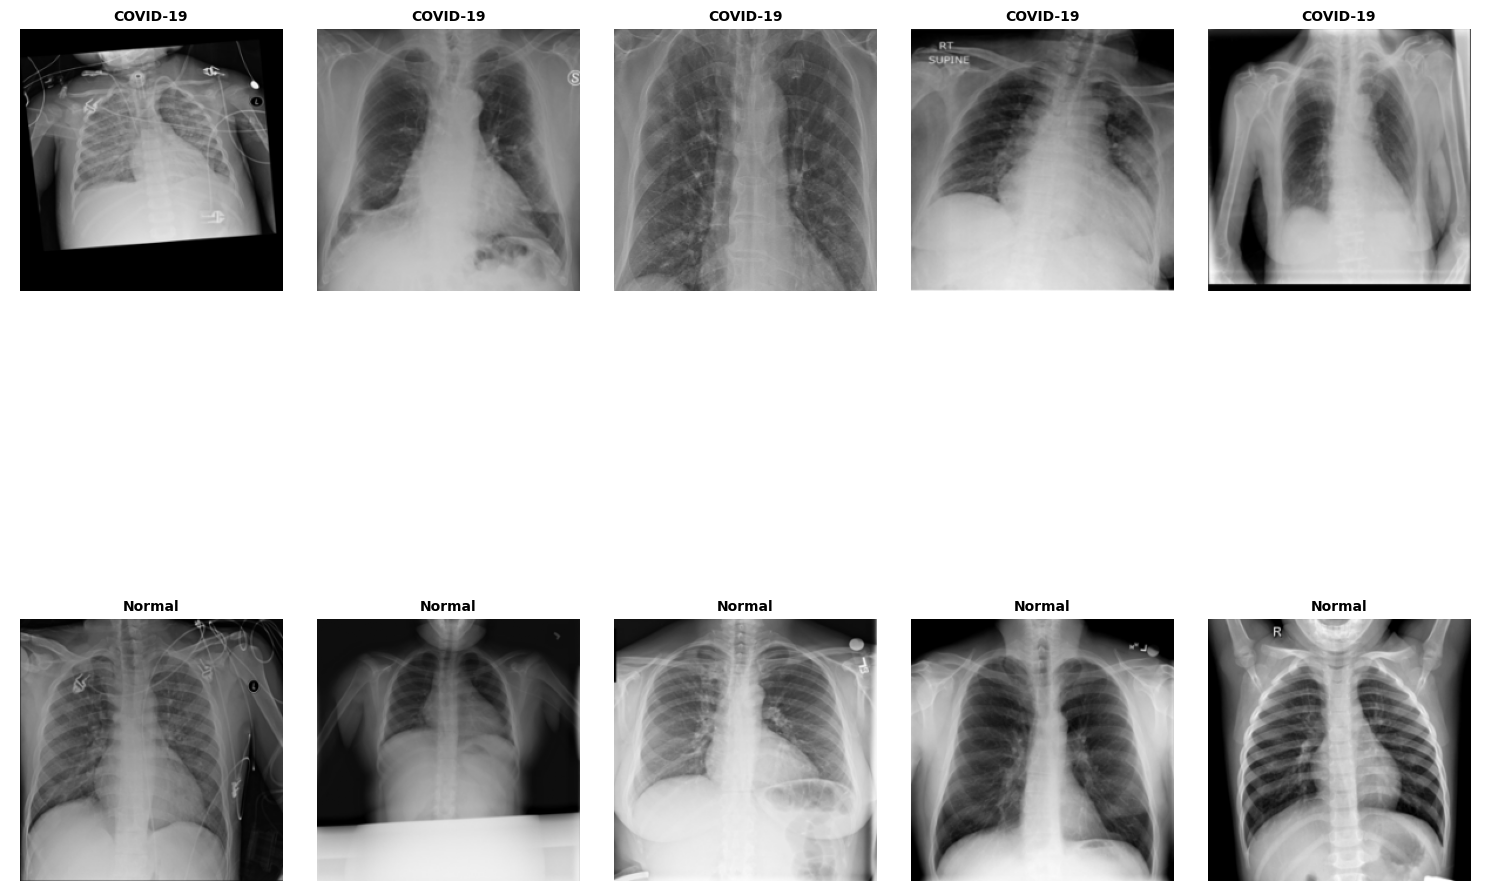

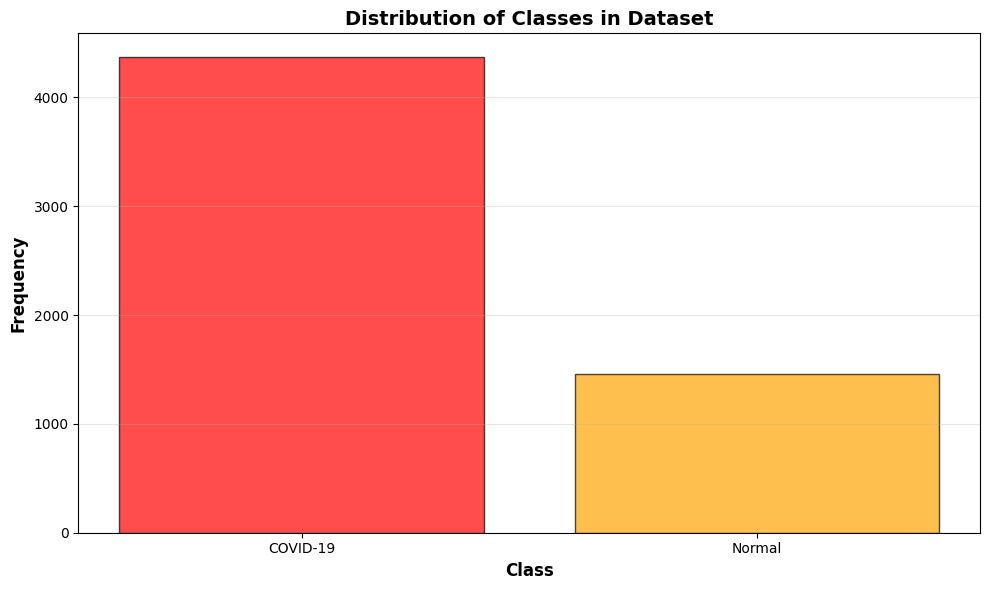


Class distribution:
  COVID-19: 4370 images (75.01%)
  Normal: 1456 images (24.99%)


In [8]:
# Visualize sample images from each class
if 'X' in locals() and 'y' in locals() and len(X) > 0:
    class_names = {0: 'COVID-19', 1: 'Non-COVID', 2: 'Normal'}
    
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    
    for class_label in [0, 1, 2]:
        class_indices = np.where(y == class_label)[0]
        if len(class_indices) > 0:
            # Show 5 random samples from this class
            sample_indices = np.random.choice(class_indices, min(5, len(class_indices)), replace=False)
            
            for idx, sample_idx in enumerate(sample_indices):
                axes[class_label, idx].imshow(X[sample_idx])
                axes[class_label, idx].set_title(f'{class_names[class_label]}', fontsize=10, fontweight='bold')
                axes[class_label, idx].axis('off')
        else:
            # Hide subplots if no images for this class
            for idx in range(5):
                axes[class_label, idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Class distribution
    plt.figure(figsize=(10, 6))
    unique, counts = np.unique(y, return_counts=True)
    class_labels = [class_names.get(u, f'Class {u}') for u in unique]
    plt.bar(class_labels, counts, edgecolor='black', alpha=0.7, color=['red', 'orange', 'green'])
    plt.xlabel('Class', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title('Distribution of Classes in Dataset', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    print(f"\nClass distribution:")
    for val, count in zip(unique, counts):
        class_name = class_names.get(val, f'Class {val}')
        print(f"  {class_name}: {count} images ({count/len(y)*100:.2f}%)")


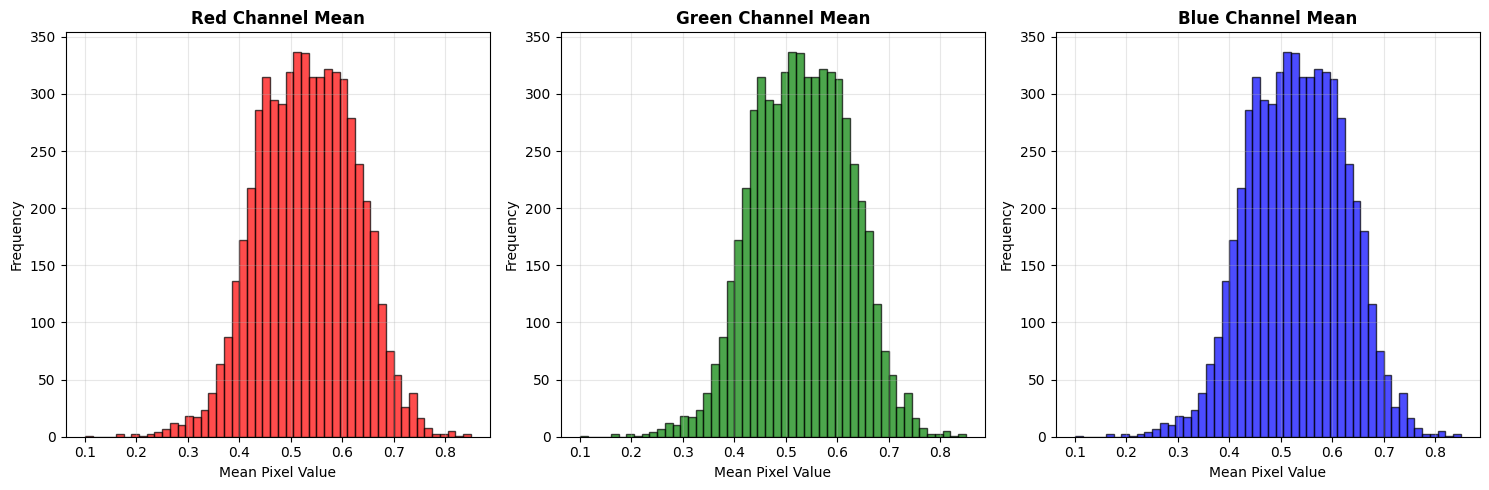


Image statistics:
  Image shape: (5826, 224, 224, 3)
  Mean pixel value (all channels): 0.5309
  Std pixel value (all channels): 0.2460
  Min pixel value: 0.0000
  Max pixel value: 1.0000


In [9]:
# Visualize image statistics
if 'X' in locals() and len(X) > 0:
    # Calculate mean pixel values per channel
    mean_values = np.mean(X, axis=(1, 2))  # Shape: (n_samples, channels)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    channel_names = ['Red', 'Green', 'Blue']
    for ch in range(min(3, mean_values.shape[1])):
        axes[ch].hist(mean_values[:, ch], bins=50, edgecolor='black', alpha=0.7, color=['red', 'green', 'blue'][ch])
        axes[ch].set_title(f'{channel_names[ch]} Channel Mean', fontsize=12, fontweight='bold')
        axes[ch].set_xlabel('Mean Pixel Value', fontsize=10)
        axes[ch].set_ylabel('Frequency', fontsize=10)
        axes[ch].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nImage statistics:")
    print(f"  Image shape: {X.shape}")
    print(f"  Mean pixel value (all channels): {np.mean(X):.4f}")
    print(f"  Std pixel value (all channels): {np.std(X):.4f}")
    print(f"  Min pixel value: {np.min(X):.4f}")
    print(f"  Max pixel value: {np.max(X):.4f}")


## 5. Train-Test Split

Splitting the data into training and testing sets.


In [10]:
# Split the data
# Note: The dataset already has Train/Val/Test splits, but we'll combine them
# and create our own splits for consistency. Alternatively, we could use the
# existing splits if we track which split each image came from.
if 'X' in locals() and 'y' in locals() and len(X) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Further split training into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print(f"Image shape: {X_train.shape[1:]}")
    
    # Check and fix label encoding - ensure labels are 0, 1, 2, ...
    print(f"\nUnique labels in full dataset: {np.unique(y)}")
    print(f"Unique labels in training set: {np.unique(y_train)}")
    print(f"Unique labels in validation set: {np.unique(y_val)}")
    print(f"Unique labels in test set: {np.unique(y_test)}")
    
    # Encode labels to be consecutive starting from 0
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_val_encoded = label_encoder.transform(y_val)
    y_test_encoded = label_encoder.transform(y_test)
    
    num_classes = len(np.unique(y_train_encoded))
    print(f"\nNumber of classes after encoding: {num_classes}")
    print(f"Encoded label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")
    
    # Convert labels to categorical for neural network
    y_train_cat = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_cat = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_cat = keras.utils.to_categorical(y_test_encoded, num_classes)
    
    # Update y_train, y_val, y_test for later use (for metrics, etc.)
    y_train = y_train_encoded
    y_val = y_val_encoded
    y_test = y_test_encoded
    
    print("Labels converted to categorical format for neural network")
    print("\nNote: Dataset has pre-existing Train/Val/Test splits, but we're")
    print("creating new splits for this analysis. To use original splits,")
    print("modify the code to track image sources.")
else:
    print("\nERROR: Cannot split data - no images were loaded.")
    print("Please check the dataset structure and ensure images are in:")
    print("  - Infection Segmentation Data/Infection Segmentation Data/Train|Val|Test/COVID-19|Non-COVID|Normal/images/")
    print("  - OR Lung Segmentation Data/Lung Segmentation Data/Train|Val|Test/COVID-19|Non-COVID|Normal/images/")


Training set: 3728 samples
Validation set: 932 samples
Test set: 1166 samples
Image shape: (224, 224, 3)

Unique labels in full dataset: [0 2]
Unique labels in training set: [0 2]
Unique labels in validation set: [0 2]
Unique labels in test set: [0 2]

Number of classes after encoding: 2
Encoded label mapping: {np.int64(0): 0, np.int64(2): 1}
Labels converted to categorical format for neural network

Note: Dataset has pre-existing Train/Val/Test splits, but we're
creating new splits for this analysis. To use original splits,
modify the code to track image sources.


## 6. Model Training

Building and training a CNN model for COVID-19 classification.


In [11]:
# Build CNN model for image classification
def create_cnn_model(input_shape=(224, 224, 3), num_classes=3):
    """Create a CNN model for COVID-19 classification"""
    model = keras.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Fourth convolutional block
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),
        
        # Flatten and dense layers
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

if 'X_train' in locals():
    input_shape = X_train.shape[1:]
    num_classes = len(np.unique(y))
    
    print(f"Creating CNN model...")
    print(f"Input shape: {input_shape}")
    print(f"Number of classes: {num_classes}")
    
    model = create_cnn_model(input_shape=input_shape, num_classes=num_classes)
    model.summary()
    
    # Callbacks
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    # Train the model
    import time
    start_time = time.time()
    
    print("\nTraining model...")
    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    training_time = time.time() - start_time
    print(f"\nModel trained in {training_time:.2f} seconds")
    
    # Make predictions
    y_pred_train = model.predict(X_train, verbose=0)
    y_pred_val = model.predict(X_val, verbose=0)
    y_pred_test = model.predict(X_test, verbose=0)
    
    # Convert predictions from probabilities to class labels
    y_pred_train = np.argmax(y_pred_train, axis=1)
    y_pred_val = np.argmax(y_pred_val, axis=1)
    y_pred_test = np.argmax(y_pred_test, axis=1)
    
    print("Predictions made on training, validation, and test sets")


Creating CNN model...
Input shape: (224, 224, 3)
Number of classes: 2


I0000 00:00:1770220963.158904      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             

 Total params: 655,810 (2.50 MB)

...


Training model...
Epoch 1/50


I0000 00:00:1770220972.918584     126 service.cc:152] XLA service 0x7bd698002b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770220972.918622     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770220973.659315     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/117 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.4670 - loss: 1.1226  

I0000 00:00:1770220982.304057     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


117/117 ━━━━━━━━━━━━━━━━━━━━ 29s 137ms/step - accuracy: 0.7198 - loss: 0.7138 - val_accuracy: 0.7500 - val_loss: 2.1146 - learning_rate: 0.0010
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7872 - loss: 0.5453 - val_accuracy: 0.7500 - val_loss: 5.1018 - learning_rate: 0.0010
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8062 - loss: 0.4788 - val_accuracy: 0.7500 - val_loss: 4.1036 - learning_rate: 0.0010
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8255 - loss: 0.4520 - val_accuracy: 0.7500 - val_loss: 1.3005 - learning_rate: 0.0010
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8420 - loss: 0.3775 - val_accuracy: 0.7500 - val_loss: 1.1948 - learning_rate: 0.0010
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8464 - loss: 0.3672 - val_accuracy: 0.7500 - val_loss: 4.2946 - learning_rate: 0.0010
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8684 - loss: 0.3153 - va

## 7. Model Evaluation

Evaluating model performance.


MODEL PERFORMANCE

Training Accuracy: 94.31%
Validation Accuracy: 91.20%
Test Accuracy: 91.51%
Training Time: 224.57 seconds

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    COVID-19       0.93      0.96      0.94       875
   Non-COVID       0.88      0.77      0.82       291

    accuracy                           0.92      1166
   macro avg       0.90      0.87      0.88      1166
weighted avg       0.91      0.92      0.91      1166



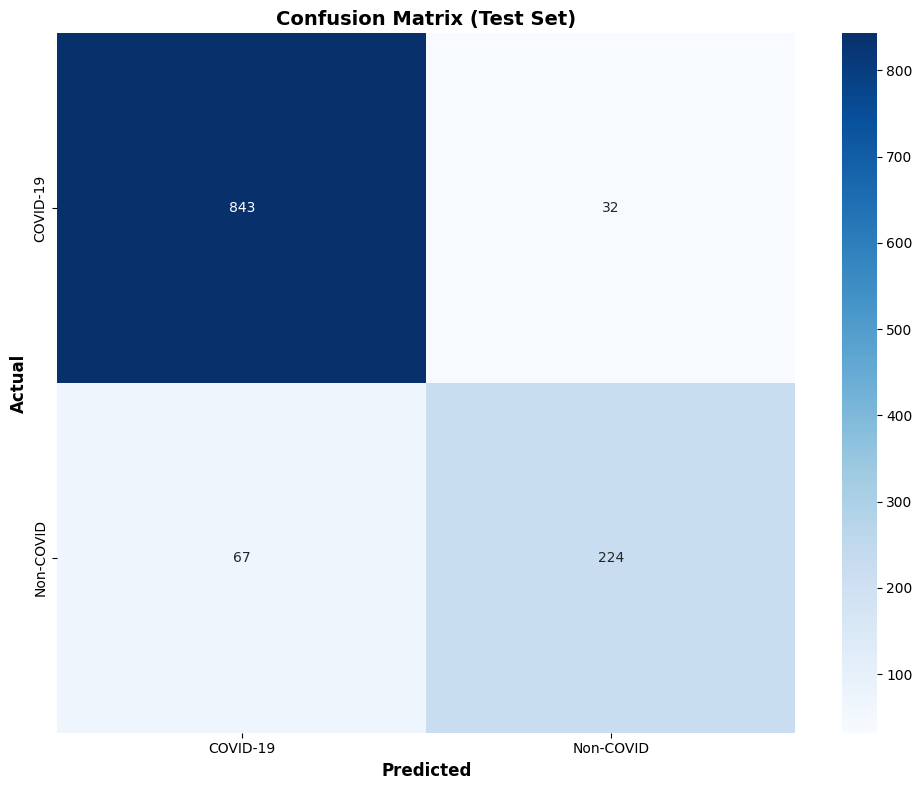

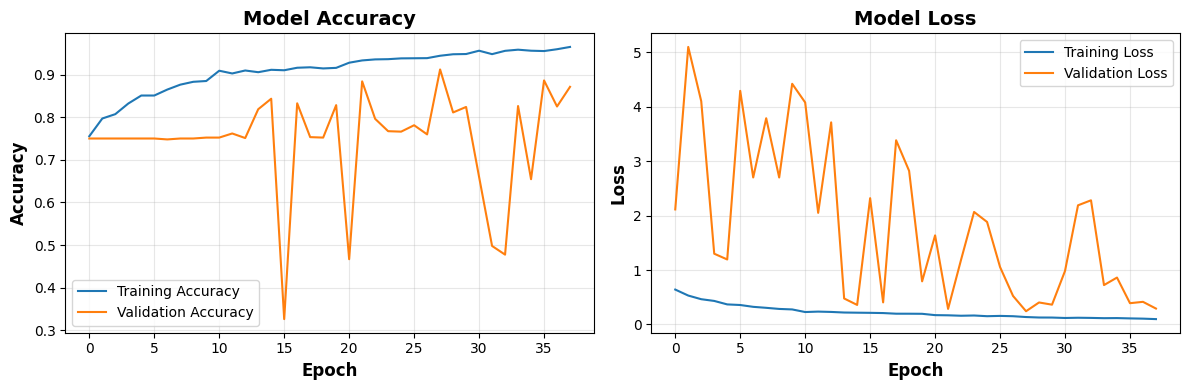

In [12]:
# Calculate metrics
if 'model' in locals() and 'history' in locals():
    train_accuracy = accuracy_score(y_train, y_pred_train)
    val_accuracy = accuracy_score(y_val, y_pred_val)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    print("="*60)
    print("MODEL PERFORMANCE")
    print("="*60)
    print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")
    print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Training Time: {training_time:.2f} seconds")
    
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT (Test Set)")
    print("="*60)
    # Get actual classes present in test set
    unique_classes = np.unique(np.concatenate([y_test, y_pred_test]))
    
    # Map class indices to names
    class_name_mapping = {0: 'COVID-19', 1: 'Non-COVID', 2: 'Normal'}
    class_names_list = [class_name_mapping.get(i, f'Class {i}') for i in sorted(unique_classes)]
    
    # Use labels parameter to specify which classes to include
    print(classification_report(y_test, y_pred_test, labels=sorted(unique_classes), 
                                target_names=class_names_list))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test, labels=sorted(unique_classes))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                xticklabels=class_names_list, yticklabels=class_names_list)
    plt.xlabel('Predicted', fontsize=12, fontweight='bold')
    plt.ylabel('Actual', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.title('Model Accuracy', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Loss', fontsize=12, fontweight='bold')
    plt.title('Model Loss', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## 8. Feature Importance

Analyzing which features are most important for predictions.


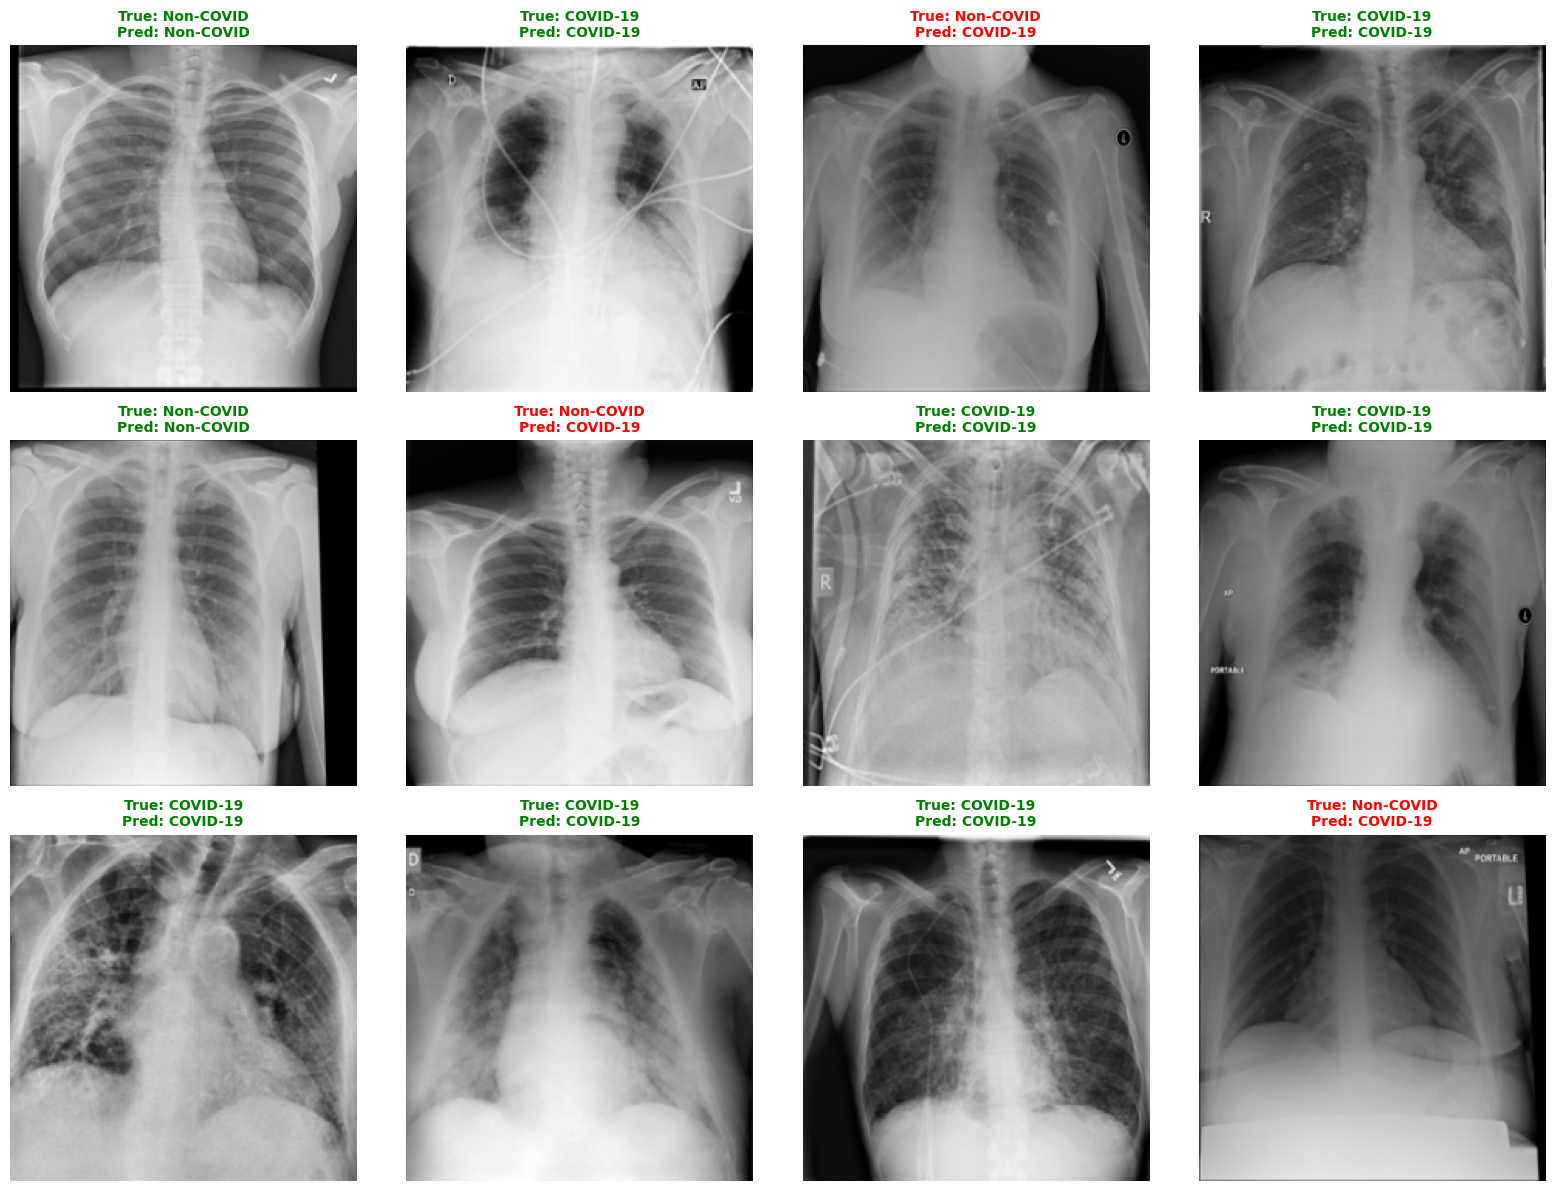


Per-Class Accuracy:
--------------------------------------------------
COVID-19: 96.34% (875 samples)
Non-COVID: 76.98% (291 samples)
--------------------------------------------------


In [13]:
# Visualize some predictions
if 'model' in locals():
    # Select some test samples to visualize
    num_samples = 12
    sample_indices = np.random.choice(len(X_test), min(num_samples, len(X_test)), replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()
    
    class_names_list = ['COVID-19', 'Non-COVID', 'Normal']
    
    for idx, sample_idx in enumerate(sample_indices):
        img = X_test[sample_idx]
        true_label = y_test[sample_idx]
        pred_label = y_pred_test[sample_idx]
        
        axes[idx].imshow(img)
        axes[idx].set_title(f'True: {class_names_list[true_label]}\nPred: {class_names_list[pred_label]}', 
                           fontsize=10, fontweight='bold',
                           color='green' if true_label == pred_label else 'red')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate per-class accuracy
    print("\nPer-Class Accuracy:")
    print("-" * 50)
    for i, class_name in enumerate(class_names_list):
        class_mask = y_test == i
        if np.sum(class_mask) > 0:
            class_accuracy = accuracy_score(y_test[class_mask], y_pred_test[class_mask])
            print(f"{class_name}: {class_accuracy * 100:.2f}% ({np.sum(class_mask)} samples)")
    print("-" * 50)


## 9. Save Model and Results

Saving the trained model and predictions.


In [14]:
# Save model and predictions
if 'model' in locals():
    model.save(f'{OUTPUT_PATH}/covidqu_model.keras')
    print(f"Model saved to {OUTPUT_PATH}/covidqu_model.keras")
    
    # Save predictions
    if 'y_pred_test' in locals():
        predictions_df = pd.DataFrame({
            'prediction': y_pred_test,
            'true_label': y_test
        })
        predictions_df['prediction_class'] = predictions_df['prediction'].map(
            {0: 'COVID-19', 1: 'Non-COVID', 2: 'Normal'}
        )
        predictions_df['true_class'] = predictions_df['true_label'].map(
            {0: 'COVID-19', 1: 'Non-COVID', 2: 'Normal'}
        )
        predictions_df.to_csv(f'{OUTPUT_PATH}/predictions.csv', index=False)
        print(f"Predictions saved to {OUTPUT_PATH}/predictions.csv")
        
        print(f"\nFirst few predictions:")
        print(predictions_df.head(10))


Model saved to /kaggle/working/covidqu_model.keras
Predictions saved to /kaggle/working/predictions.csv

First few predictions:
   prediction  true_label prediction_class true_class
0           0           0         COVID-19   COVID-19
1           0           0         COVID-19   COVID-19
2           0           0         COVID-19   COVID-19
3           0           0         COVID-19   COVID-19
4           0           0         COVID-19   COVID-19
5           0           0         COVID-19   COVID-19
6           0           0         COVID-19   COVID-19
7           0           0         COVID-19   COVID-19
8           1           1        Non-COVID  Non-COVID
9           1           1        Non-COVID  Non-COVID


## 10. Summary and Conclusions

### Key Findings:
- Dataset successfully loaded: COVID-QU-Ex dataset
  - COVID-19 cases
  - Non-COVID cases (Viral or Bacterial Pneumonia)
  - Normal cases
- Dataset structure: Images organized in Train/Val/Test splits with class subdirectories
- CNN model trained and evaluated on the COVID-QU dataset
- Model can classify chest X-rays into three categories: COVID-19, Non-COVID, Normal

### Model Performance:
- See evaluation metrics above (accuracy, confusion matrix, per-class metrics)

### Potential Improvements:
- Use transfer learning with pre-trained models (ResNet, VGG, EfficientNet)
- Apply data augmentation techniques (rotation, flipping, brightness adjustment)
- Use lung segmentation masks to focus on relevant regions
- Perform hyperparameter tuning
- Try ensemble methods
- Use class weights to handle any class imbalance
- Implement Grad-CAM for model interpretability
- Use cross-validation for more robust evaluation
